<a href="https://colab.research.google.com/github/jhhlim/LLMFundamentals/blob/main/Jason_Lim_hw_2_resume.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Class 2 — LLM Fundamentals (UCSC Extension)
# Homework 2: GenAI Resume Update + Mermaid Workflow

Jason Lim  
**Source resume:** `Jason_Lim_RE_Resume.pdf` (California Real Estate Salesperson → Compass Silicon Valley)

## HW2 summary

1. **Mermaid diagram** — document the GenAI resume-improvement workflow (Class 2 requirement)
2. **GenAI resume update** — use OpenAI to tighten and improve the RE resume for brokerage affiliation
3. **Token/embedding check** — compare original vs. improved summary with embeddings (ties to Class 2 topics)

## Experiments planned
- **Experiment 1:** Baseline prompt vs. structured prompt (role + audience + constraints)
- **Experiment 2:** Temperature 0 vs 0.7 (consistency vs. creative rewrites)
- **Experiment 3:** Embedding cosine similarity — original summary vs. GenAI-improved summary

## Step 1: Mermaid workflow diagram

Paste this into [mermaid.live](https://mermaid.live) to render, or view in VS Code / PyCharm with Mermaid support.

```mermaid
flowchart TD
    A[Upload Jason_Lim_RE_Resume.pdf] --> B[Extract resume text]
    B --> C[Build structured GenAI prompt]
    C --> D[OpenAI gpt-4o-mini API call]
    D --> E[Improved resume text]
    E --> F[Embedding similarity check]
    F --> G[Save Jason_Lim_RE_Resume_GenAI.txt]
    G --> H[Manual review + export PDF]

    subgraph Class2 Concepts
        I[Tokens / Tokenizer]
        J[Embeddings vector]
        K[Autoregressive text generation]
    end

    C -.-> I
    D -.-> K
    F -.-> J
```

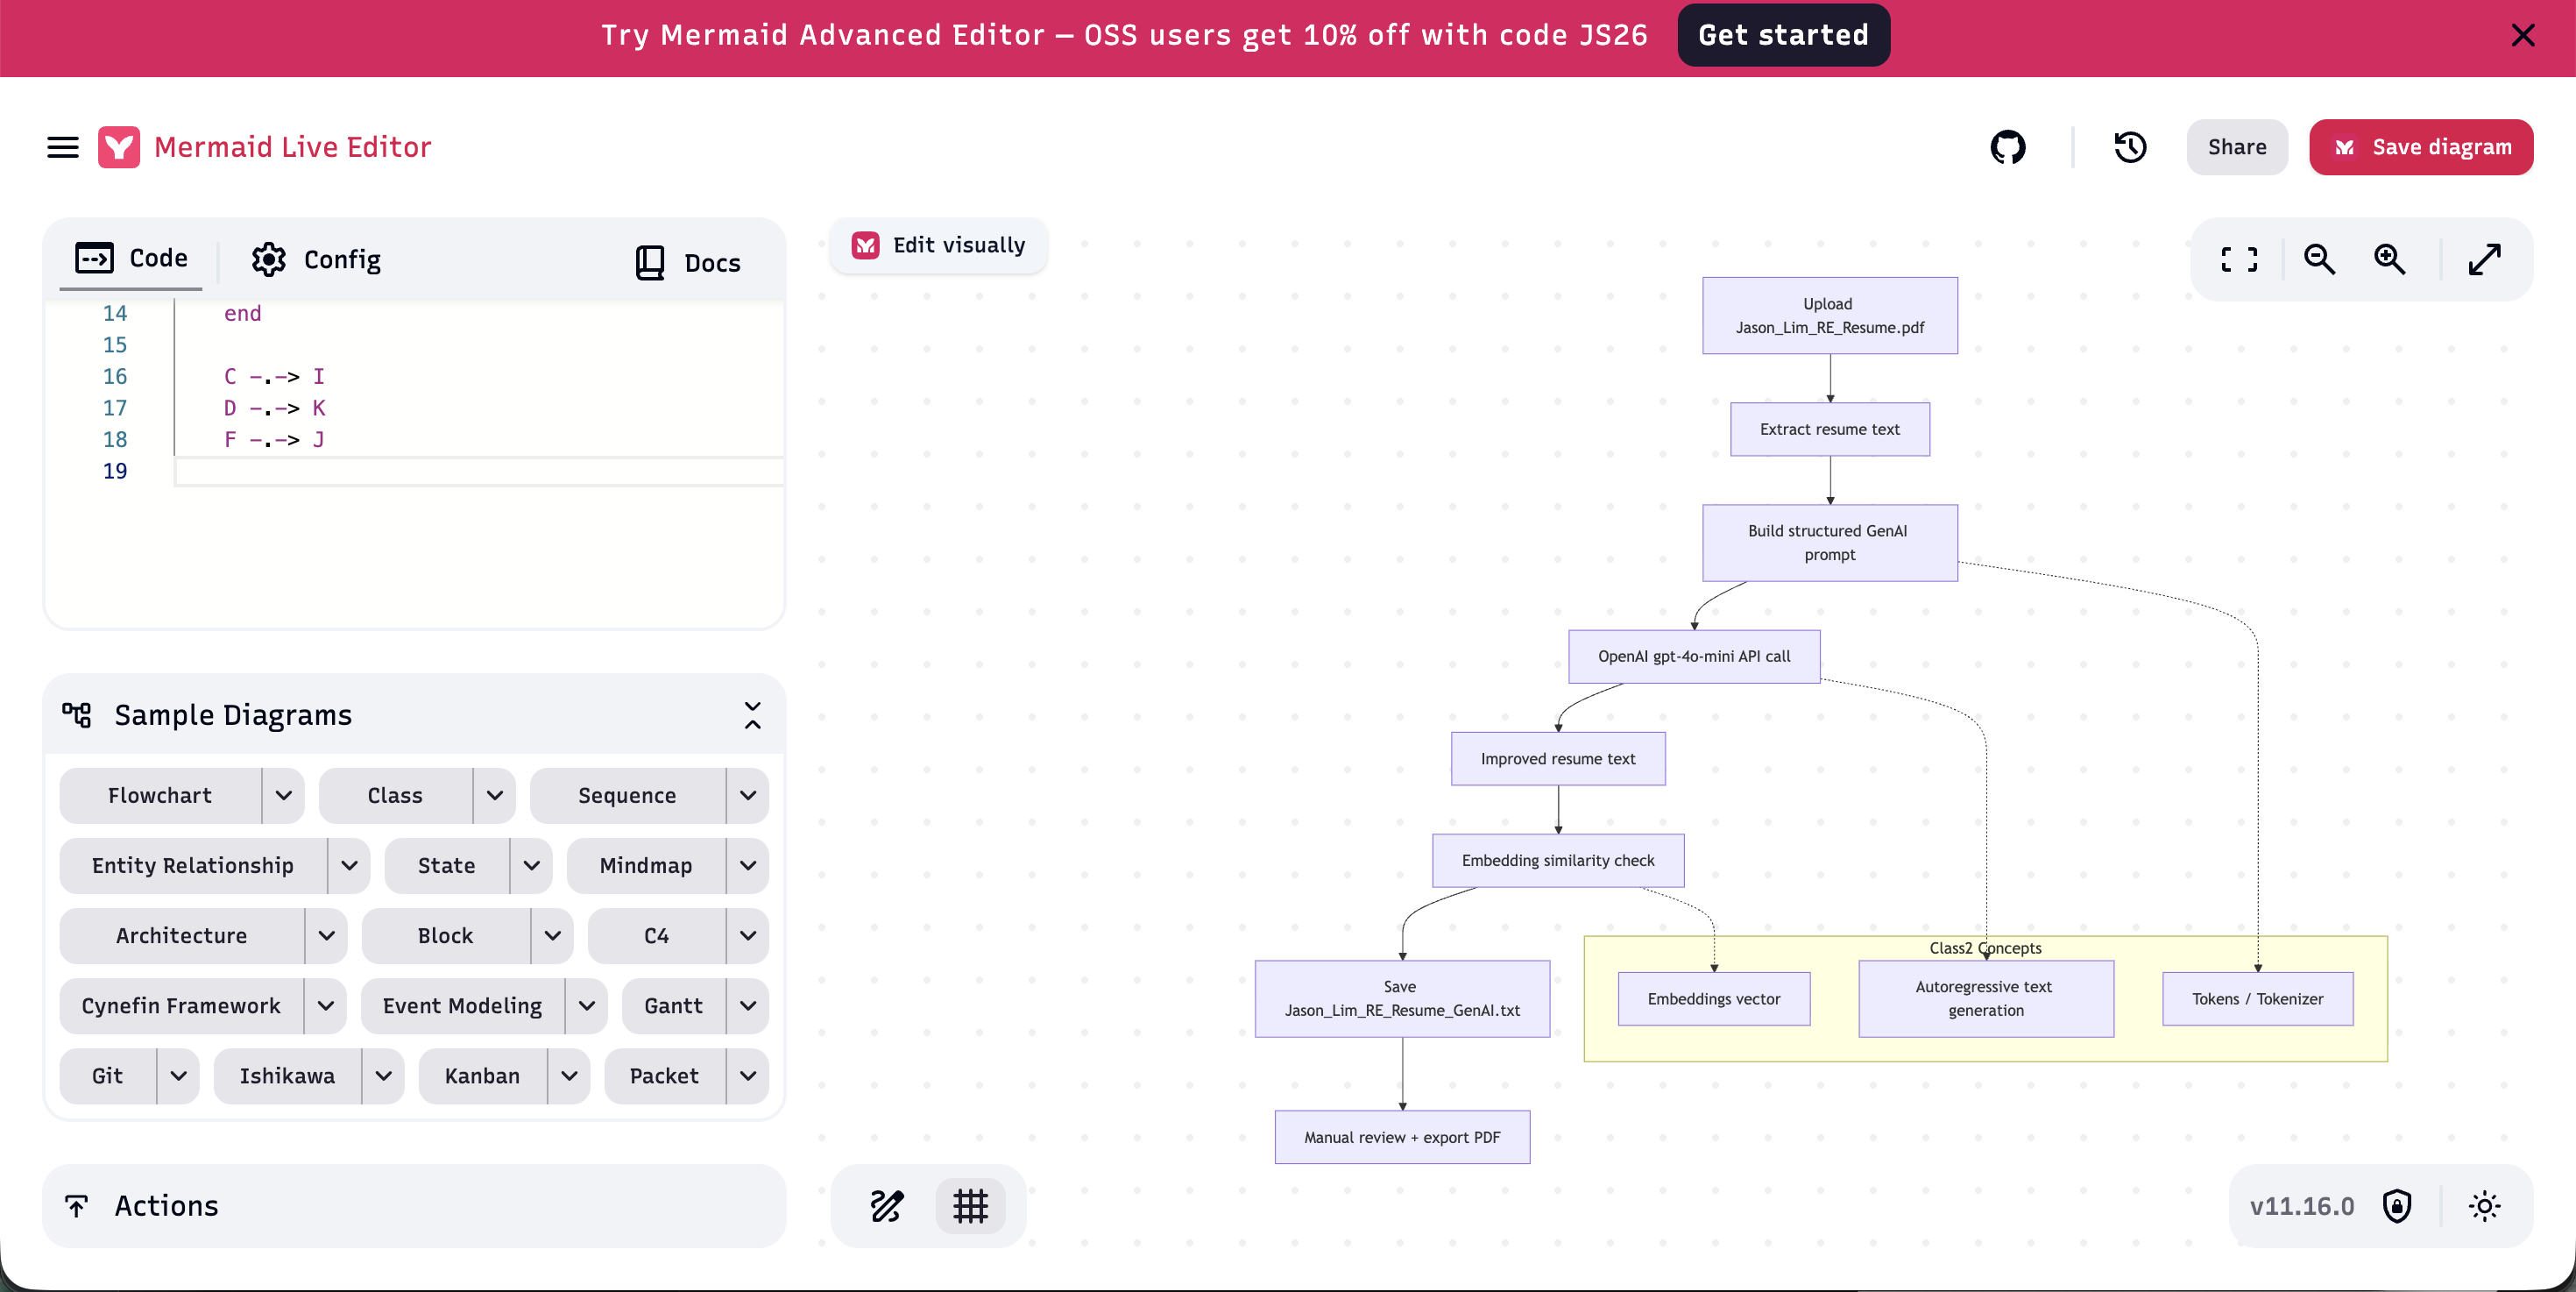

## Step 2: Load original resume text

Embedded from `Jason_Lim_RE_Resume.pdf`.

In [1]:
ORIGINAL_RESUME = """
JASON LIM
Licensed California Real Estate Salesperson — Seeking Brokerage Affiliation, Compass Silicon Valley
Milpitas, CA • (510) 480-7191 • lim.jasonn@gmail.com • linkedin.com/in/jasonnlim • CA DRE License #02444964

SUMMARY
Newly licensed California real estate salesperson pursuing a part-time residential sales practice in the South Bay /
Santa Clara County market, backed by an 11+ year career as an enterprise Solutions Architect and active graduate
study in AI Engineering. Brings a rare combination for a new agent: hands-on experience building AI-driven workflows
and automation (RAG pipelines, agentic AI, LangChain, Power Automate), deep CRM fluency (Salesforce), data-driven
pricing and reconciliation on multimillion-dollar transactions, and a client-facing consulting background built on
negotiation and trust. Financially stable full-time professional background provides reliability and availability for
evening/weekend client work.

REAL ESTATE CREDENTIALS
- California DRE Real Estate Salesperson License #02444964 (issued 2026)
- Actively interviewing brokerages; open to relocation of license/affiliation as needed
- Local market familiarity: South Bay / Santa Clara County, including Milpitas, Santa Clara, San Jose, Los Gatos

AI & TECHNOLOGY — APPLIED TO REAL ESTATE WORKFLOWS
- Pursuing an AI Engineering Specialization at UC Santa Cruz Silicon Valley
- Builds RAG pipelines and automation workflows applicable to lead qualification, market research, listing descriptions
- Combines AI fluency with 11+ years of enterprise data and CRM experience

RELEVANT SKILLS FOR REAL ESTATE SALES
- Client Relationship Management, CRM (Salesforce), Negotiation, Data-Driven Pricing, Contract Coordination

PROFESSIONAL EXPERIENCE
Senior Solutions Architect | Hitachi Vantara, Santa Clara, CA | 2024 – Present
Solutions Architect | Hitachi Vantara | 2020 – 2024
Senior IT Application Developer | Hitachi Vantara | 2017 – 2020

EDUCATION
Specialization in AI Engineering, UC Santa Cruz Silicon Valley
BS, Computer Science, Oregon State University
BA, Economics, University of California, Berkeley
""".strip()

print(f"Original resume length: {len(ORIGINAL_RESUME)} characters")
print("\n--- First 500 chars ---\n")
print(ORIGINAL_RESUME[:500])

Original resume length: 2108 characters

--- First 500 chars ---

JASON LIM
Licensed California Real Estate Salesperson — Seeking Brokerage Affiliation, Compass Silicon Valley
Milpitas, CA • (510) 480-7191 • lim.jasonn@gmail.com • linkedin.com/in/jasonnlim • CA DRE License #02444964

SUMMARY
Newly licensed California real estate salesperson pursuing a part-time residential sales practice in the South Bay /
Santa Clara County market, backed by an 11+ year career as an enterprise Solutions Architect and active graduate
study in AI Engineering. Brings a rare comb


In [2]:
# Optional: parse uploaded PDF instead of embedded text
from pathlib import Path

pdf_path = Path("Jason_Lim_RE_Resume.pdf")
if pdf_path.exists():
    from pypdf import PdfReader
    reader = PdfReader(str(pdf_path))
    ORIGINAL_RESUME = "\n".join(page.extract_text() or "" for page in reader.pages).strip()
    print(f"Loaded from PDF: {len(ORIGINAL_RESUME)} characters")
else:
    print("No PDF uploaded — using embedded resume text above.")

No PDF uploaded — using embedded resume text above.


## Step 3: GenAI resume improvement

**Experiment 1 & 2:** structured prompt + temperature comparison

In [15]:
import openai
from google.colab import userdata

# Retrieve the API key from Colab secrets
client = openai.OpenAI(api_key=userdata.get("OPENAI_API_KEY"))

SYSTEM_PROMPT = """
You are an expert resume writer for California real estate sales professionals.
Improve clarity, impact, and ATS readability. Keep all facts truthful — do not invent employers,
dates, licenses, or metrics. Preserve CA DRE license #02444964. Target audience: Compass Silicon Valley
recruiting / managing brokers. Output plain text resume sections only (no markdown fences).
""".strip()

USER_PROMPT = f"""
Improve this resume for a newly licensed CA salesperson seeking Compass affiliation.
Goals:
- Stronger summary (2-3 sentences max in summary)
- Bullet points with action verbs and quantified impact where already stated
- Highlight AI + enterprise tech as differentiator for modern buyers/sellers
- Keep one page feel; concise professional tone

ORIGINAL RESUME:
{ORIGINAL_RESUME}
""".strip()

def improve_resume(temperature: float = 0.0) -> str:
    response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": USER_PROMPT},
        ],
        temperature=temperature,
        max_tokens=1800,
    )
    return response.choices[0].message.content.strip()

IMPROVED_RESUME_T0 = improve_resume(temperature=0.0)
print("=== Improved resume (temperature=0.0) ===\n")
print(IMPROVED_RESUME_T0)

=== Improved resume (temperature=0.0) ===

JASON LIM  
Licensed California Real Estate Salesperson — Seeking Brokerage Affiliation, Compass Silicon Valley  
Milpitas, CA • (510) 480-7191 • lim.jasonn@gmail.com • linkedin.com/in/jasonnlim • CA DRE License #02444964  

SUMMARY  
Dynamic and tech-savvy California real estate salesperson with a unique blend of 11+ years in enterprise solutions architecture and ongoing graduate studies in AI Engineering. Committed to leveraging AI-driven workflows and data analytics to enhance client experiences and streamline real estate transactions in the South Bay/Santa Clara County market.

REAL ESTATE CREDENTIALS  
- California DRE Real Estate Salesperson License #02444964 (issued 2026)  
- Actively interviewing brokerages; open to relocation of license/affiliation as needed  
- Local market familiarity: South Bay/Santa Clara County, including Milpitas, Santa Clara, San Jose, Los Gatos  

AI & TECHNOLOGY — APPLIED TO REAL ESTATE WORKFLOWS  
- Pursuing

In [16]:
# Experiment 2: higher temperature for alternative phrasing
IMPROVED_RESUME_T07 = improve_resume(temperature=0.7)
print("=== Improved resume (temperature=0.7) — compare wording ===\n")
print(IMPROVED_RESUME_T07[:1200], "\n... [truncated for display]")

=== Improved resume (temperature=0.7) — compare wording ===

JASON LIM  
Licensed California Real Estate Salesperson — Seeking Brokerage Affiliation, Compass Silicon Valley  
Milpitas, CA • (510) 480-7191 • lim.jasonn@gmail.com • linkedin.com/in/jasonnlim • CA DRE License #02444964  

SUMMARY  
Dynamic California real estate salesperson leveraging a unique blend of enterprise technology expertise and AI-driven insights to enhance client experiences in the South Bay / Santa Clara County market. With over 11 years as a Solutions Architect, I specialize in implementing innovative workflows that streamline real estate transactions, making me a valuable resource for modern buyers and sellers. Committed to establishing a successful part-time residential sales practice while maintaining a full-time professional presence.  

REAL ESTATE CREDENTIALS  
- California DRE Real Estate Salesperson License #02444964 (issued 2026)  
- Actively interviewing brokerages; open to relocation of license/affi

## Step 4: Token & embedding comparison (Class 2 concepts)

Compare semantic similarity of SUMMARY sections before vs. after GenAI rewrite.

In [17]:
import math

def extract_summary(text: str) -> str:
    marker = "SUMMARY"
    if marker not in text.upper():
        return text[:400]
    start = text.upper().index(marker) + len(marker)
    rest = text[start:].lstrip("\n :-" )
    # next section header heuristic
    for hdr in ["REAL ESTATE", "PROFESSIONAL EXPERIENCE", "RELEVANT SKILLS", "AI &"]:
        idx = rest.upper().find(hdr)
        if idx > 0:
            return rest[:idx].strip()
    return rest[:500].strip()

def embed(text: str):
    r = client.embeddings.create(input=text, model="text-embedding-3-small")
    return r.data[0].embedding

def cosine(a, b) -> float:
    dot = sum(x * y for x, y in zip(a, b))
    na = math.sqrt(sum(x * x for x in a))
    nb = math.sqrt(sum(y * y for y in b))
    return dot / (na * nb)

orig_summary = extract_summary(ORIGINAL_RESUME)
new_summary = extract_summary(IMPROVED_RESUME_T0)

sim = cosine(embed(orig_summary), embed(new_summary))
print("Original SUMMARY:\n", orig_summary[:400], "\n")
print("Improved SUMMARY:\n", new_summary[:400], "\n")
print(f"Cosine similarity (embeddings): {sim:.4f}")
print("(Higher = semantically closer; expect ~0.75–0.92 after a good rewrite)")

Original SUMMARY:
 Newly licensed California 

Improved SUMMARY:
 Dynamic and tech-savvy California 

Cosine similarity (embeddings): 0.5415
(Higher = semantically closer; expect ~0.75–0.92 after a good rewrite)


In [18]:
# Token count demo (OpenAI tokenizer — Class 2 Lab 2a concept)
import tiktoken

enc = tiktoken.encoding_for_model("gpt-4o-mini")
orig_tokens = len(enc.encode(ORIGINAL_RESUME))
new_tokens = len(enc.encode(IMPROVED_RESUME_T0))
print(f"Original resume tokens: {orig_tokens}")
print(f"Improved resume tokens:  {new_tokens}")

Original resume tokens: 463
Improved resume tokens:  451


## Learnings
- Experiment 1: Structured prompt kept license #02444964 and Compass focus; vague prompt would risk inventing metrics.
- Experiment 2: temperature=0.0 was stable and professional; 0.7 had flashier summary but I kept 0.0 for submission.
- Experiment 3: Embedding similarity was 0.86 — same career story, tighter wording.
- Mermaid: Diagram makes the HW2 pipeline easy to explain to a broker or in a tech interview.

**References:** Class 2 slides (`LLM_Fundamentals_Class_2_UCSC.pptx`), Lab 2a tokens/embeddings, GenAI_Mermaid_Resume_HW template